# Machine Learning Modelling

## Objective

This notebook develops and evaluates regression models for predicting
canton-level home-ownership rates from household composition, demographic
structure, and canton population size.

The modelling dataset contains 156 canton-year observations covering 26 Swiss
cantons from 2019 to 2024.

Particular attention is given to the validation strategy because observations
from different years of the same canton are not independent. The exploratory
analysis showed that between-canton variation in home ownership is substantially
larger than within-canton temporal variation.

In [1]:
# Standard library imports
from pathlib import Path

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import joblib


# Resolve the project root from the notebook directory.
PROJECT_ROOT = Path("..").resolve()

## Modelling Data

The modelling stage uses the processed dataset produced by the EDA and feature
engineering workflow. Identifiers are retained for validation and traceability
but are excluded from the predictor matrix.

In [2]:
# Define the path to the modelling dataset generated during EDA.
MODELLING_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "canton_year_modelling_dataset_2019_2024.csv"
)

# Load the final modelling dataset.
df = pd.read_csv(MODELLING_DATA_PATH)

print("Dataset shape:", df.shape)
print("Cantons:", df["GEO"].nunique())
print("Years:", df["YEAR"].nunique())

display(df.head())

Dataset shape: (156, 13)
Cantons: 26
Years: 6


,YEAR,GEO,CANTON,HOME_OWNERSHIP_RATE,SHARE_1_PERSON_HOUSEHOLDS,SHARE_2_PERSON_HOUSEHOLDS,SHARE_3_PERSON_HOUSEHOLDS,SHARE_4_PERSON_HOUSEHOLDS,SHARE_5_PERSON_HOUSEHOLDS,SHARE_AGE_20_39,SHARE_AGE_40_64,SHARE_AGE_65_PLUS,LOG_TOTAL_POPULATION
0,2019,CH040,Zürich,27.7,0.367545,0.328809,0.128719,0.123278,0.037609,0.286642,0.345333,0.170467,14.246823
1,2019,CH021,Bern / Berne,38.8,0.369592,0.349634,0.116326,0.112822,0.037671,0.251335,0.347803,0.210628,13.854180
2,2019,CH061,Luzern,34.4,0.340769,0.340083,0.123593,0.131391,0.047341,0.273693,0.344943,0.178483,12.931496
3,2019,CH062,Uri,42.9,0.316149,0.356410,0.120911,0.135493,0.053229,0.243795,0.347846,0.207912,10.510641
4,2019,CH063,Schwyz,39.4,0.326473,0.349536,0.130921,0.130762,0.045982,0.249969,0.375685,0.181524,11.985931


***REPORT NOTE*** - *Validation strategy*

The dataset has a panel structure with repeated yearly observations for each canton. Exploratory analysis showed that between-canton variation in the target was approximately 10.5 times larger than average within-canton temporal variation. A conventional random observation-level split could therefore produce overly optimistic estimates by placing different years of the same canton in both training and validation data. A group-aware validation strategy was consequently adopted, using canton as the grouping variable.

## Validation Strategy

The dataset contains repeated yearly observations for each canton. A random
observation-level split could place different years of the same canton in both
training and validation sets, introducing dependence between the two samples.

To evaluate whether the models generalise across cantons, group-aware
cross-validation is used. Canton (`GEO`) defines the grouping variable, ensuring
that all six yearly observations of a canton remain within the same fold.

Five-fold GroupKFold cross-validation is used throughout the main model
comparison.

In [3]:
# Define columns that are not used as model predictors.
identifier_columns = [
    "YEAR",
    "GEO",
    "CANTON",
]

target = "HOME_OWNERSHIP_RATE"


# Construct the predictor matrix.
X = df.drop(
    columns=identifier_columns + [target]
)

# Define the regression target.
y = df[target]

# Use canton as the grouping variable for cross-validation.
groups = df["GEO"]


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of predictors:", X.shape[1])
print("Number of groups:", groups.nunique())

display(X.head())

X shape: (156, 9)
y shape: (156,)
Number of predictors: 9
Number of groups: 26


,SHARE_1_PERSON_HOUSEHOLDS,SHARE_2_PERSON_HOUSEHOLDS,SHARE_3_PERSON_HOUSEHOLDS,SHARE_4_PERSON_HOUSEHOLDS,SHARE_5_PERSON_HOUSEHOLDS,SHARE_AGE_20_39,SHARE_AGE_40_64,SHARE_AGE_65_PLUS,LOG_TOTAL_POPULATION
0,0.367545,0.328809,0.128719,0.123278,0.037609,0.286642,0.345333,0.170467,14.246823
1,0.369592,0.349634,0.116326,0.112822,0.037671,0.251335,0.347803,0.210628,13.854180
2,0.340769,0.340083,0.123593,0.131391,0.047341,0.273693,0.344943,0.178483,12.931496
3,0.316149,0.356410,0.120911,0.135493,0.053229,0.243795,0.347846,0.207912,10.510641
4,0.326473,0.349536,0.130921,0.130762,0.045982,0.249969,0.375685,0.181524,11.985931


In [4]:
# Create group-aware cross-validation.
# All observations from the same canton remain together
# in either training or validation within each fold.
cv = GroupKFold(
    n_splits=5,
)

In [5]:
# Inspect the canton allocation in each validation fold and verify
# that no canton appears simultaneously in training and validation.
for fold, (train_idx, validation_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1,
):
    train_cantons = set(
        groups.iloc[train_idx]
    )

    validation_cantons = set(
        groups.iloc[validation_idx]
    )

    overlap = train_cantons.intersection(
        validation_cantons
    )

    print(
        f"Fold {fold}: "
        f"{len(train_idx)} train observations, "
        f"{len(validation_idx)} validation observations, "
        f"{len(validation_cantons)} validation cantons"
    )

    assert len(overlap) == 0

Fold 1: 120 train observations, 36 validation observations, 6 validation cantons
Fold 2: 126 train observations, 30 validation observations, 5 validation cantons
Fold 3: 126 train observations, 30 validation observations, 5 validation cantons
Fold 4: 126 train observations, 30 validation observations, 5 validation cantons
Fold 5: 126 train observations, 30 validation observations, 5 validation cantons


## Baseline Model

A mean-based dummy regressor is used as the reference model. Within each
cross-validation fold, the model predicts the mean home-ownership rate observed
in the training cantons.

This baseline provides a minimum reference against which the predictive
performance of the machine-learning models can be evaluated. The same
group-aware cross-validation strategy is used for the baseline and all
subsequent models.

In [6]:
# Define a simple mean-based baseline model.
baseline_model = DummyRegressor(
    strategy="mean",
)


# Generate out-of-fold predictions using the same
# canton-grouped cross-validation strategy.
baseline_predictions = cross_val_predict(
    baseline_model,
    X,
    y,
    cv=cv,
    groups=groups,
)

In [7]:
# Evaluate the out-of-fold baseline predictions.
baseline_mae = mean_absolute_error(
    y,
    baseline_predictions,
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y,
        baseline_predictions,
    )
)

baseline_r2 = r2_score(
    y,
    baseline_predictions,
)


print(f"Baseline MAE:  {baseline_mae:.2f} percentage points")
print(f"Baseline RMSE: {baseline_rmse:.2f} percentage points")
print(f"Baseline R²:   {baseline_r2:.3f}")

Baseline MAE:  7.51 percentage points
Baseline RMSE: 9.74 percentage points
Baseline R²:   -0.049


***REPORT NOTE*** - *Baseline*

A mean-based dummy regressor was evaluated using the same group-aware cross-validation procedure as the predictive models. This provides a leakage-free reference performance and allows subsequent model improvements to be quantified in interpretable percentage-point errors.

***REPORT NOTE*** - *Baseline performance*

Under canton-grouped cross-validation, the mean-based baseline achieved an MAE of 7.51 percentage points and an RMSE of 9.74 percentage points. Its out-of-fold R² was −0.049. These results establish the reference performance that subsequent regression models must improve upon.

|## Linear Regression

Linear regression is used as the first predictive model to establish whether
the engineered demographic and household features can explain home-ownership
differences through a simple linear relationship.

Predictors are standardised within each training fold using a scikit-learn
pipeline. Performing preprocessing inside the cross-validation procedure
prevents information from the validation cantons from being used during
feature scaling.

In [8]:
# Create a linear regression pipeline.
#
# StandardScaler is fitted independently within each training fold,
# preventing information from the validation cantons from entering
# the preprocessing stage.
linear_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LinearRegression(),
        ),
    ]
)

In [9]:
# Generate out-of-fold predictions using exactly the same
# canton-grouped cross-validation strategy as the baseline.
linear_predictions = cross_val_predict(
    linear_model,
    X,
    y,
    cv=cv,
    groups=groups,
)

In [10]:
# Evaluate linear regression using the out-of-fold predictions.
linear_mae = mean_absolute_error(
    y,
    linear_predictions,
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y,
        linear_predictions,
    )
)

linear_r2 = r2_score(
    y,
    linear_predictions,
)


print(f"Linear Regression MAE:  {linear_mae:.2f} percentage points")
print(f"Linear Regression RMSE: {linear_rmse:.2f} percentage points")
print(f"Linear Regression R²:   {linear_r2:.3f}")

Linear Regression MAE:  8.71 percentage points
Linear Regression RMSE: 11.56 percentage points
Linear Regression R²:   -0.479


***REPORT NOTE*** - *Linear model performance*
Linear regression did not improve upon the mean-based baseline under canton-grouped cross-validation. The model achieved an MAE of 8.71 percentage points, an RMSE of 11.56 percentage points, and an out-of-fold R² of −0.479, compared with 7.51, 9.74, and −0.049 for the baseline. This indicates that a simple linear relationship between the engineered predictors and home-ownership rates does not generalise effectively to previously unseen cantons.

## Random Forest Regression

A Random Forest regressor is evaluated to determine whether nonlinear
relationships and interactions between demographic and household features
improve generalisation across cantons.

The model is evaluated using the same canton-grouped cross-validation procedure
as the baseline and linear regression, ensuring directly comparable results.

In [11]:
# Define a nonlinear tree-based regression model.
#
# A minimum leaf size greater than one provides some regularisation,
# which is particularly relevant given the small dataset.
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)


# Generate out-of-fold predictions using the same
# canton-grouped cross-validation strategy.
random_forest_predictions = cross_val_predict(
    random_forest_model,
    X,
    y,
    cv=cv,
    groups=groups,
    n_jobs=-1,
)

In [12]:
# Evaluate Random Forest using the out-of-fold predictions.
random_forest_mae = mean_absolute_error(
    y,
    random_forest_predictions,
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y,
        random_forest_predictions,
    )
)

random_forest_r2 = r2_score(
    y,
    random_forest_predictions,
)


print(
    f"Random Forest MAE:  "
    f"{random_forest_mae:.2f} percentage points"
)

print(
    f"Random Forest RMSE: "
    f"{random_forest_rmse:.2f} percentage points"
)

print(
    f"Random Forest R²:   "
    f"{random_forest_r2:.3f}"
)

Random Forest MAE:  6.56 percentage points
Random Forest RMSE: 7.86 percentage points
Random Forest R²:   0.317


***REPORT NOTE*** - Random Forest performance

Random Forest substantially improved predictive performance compared with both the mean-based baseline and linear regression. Under canton-grouped cross-validation, the model achieved an MAE of 6.56 percentage points, an RMSE of 7.86 percentage points, and an out-of-fold R² of 0.317. Relative to the baseline MAE of 7.51 percentage points, this corresponds to an error reduction of approximately 12.6%. The improvement suggests that demographic and household characteristics contain predictive information for differences in home-ownership rates across cantons, but that these relationships are not adequately represented by a simple linear model.

## Gradient Boosting Regression

Gradient Boosting is evaluated as a second nonlinear modelling approach.
Unlike Random Forest, which averages multiple independently constructed trees,
Gradient Boosting builds trees sequentially to progressively correct prediction
errors.

The model is evaluated using the same canton-grouped cross-validation strategy
to ensure direct comparability with all previous models.

In [13]:
# Define a moderately regularised Gradient Boosting model.
# Conservative parameters are used given the small sample size,
# without performing hyperparameter optimisation.
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)


# Generate out-of-fold predictions using the same
# canton-grouped cross-validation strategy.
gradient_boosting_predictions = cross_val_predict(
    gradient_boosting_model,
    X,
    y,
    cv=cv,
    groups=groups,
)

In [14]:
# Evaluate Gradient Boosting using the out-of-fold predictions.
gradient_boosting_mae = mean_absolute_error(
    y,
    gradient_boosting_predictions,
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(
        y,
        gradient_boosting_predictions,
    )
)

gradient_boosting_r2 = r2_score(
    y,
    gradient_boosting_predictions,
)


print(
    f"Gradient Boosting MAE:  "
    f"{gradient_boosting_mae:.2f} percentage points"
)

print(
    f"Gradient Boosting RMSE: "
    f"{gradient_boosting_rmse:.2f} percentage points"
)

print(
    f"Gradient Boosting R²:   "
    f"{gradient_boosting_r2:.3f}"
)

Gradient Boosting MAE:  6.05 percentage points
Gradient Boosting RMSE: 7.62 percentage points
Gradient Boosting R²:   0.359


## Model Comparison

The four modelling approaches are compared using the same out-of-fold
predictions generated through canton-grouped cross-validation.

MAE is used as the primary evaluation metric because it expresses prediction
error directly in percentage points of the home-ownership rate. RMSE and R²
are reported as complementary measures of large prediction errors and overall
explained variation.

In [15]:
# Collect the cross-validated performance of all evaluated models.
model_results = pd.DataFrame(
    {
        "Model": [
            "Baseline",
            "Linear Regression",
            "Random Forest",
            "Gradient Boosting",
        ],
        "MAE": [
            baseline_mae,
            linear_mae,
            random_forest_mae,
            gradient_boosting_mae,
        ],
        "RMSE": [
            baseline_rmse,
            linear_rmse,
            random_forest_rmse,
            gradient_boosting_rmse,
        ],
        "R2": [
            baseline_r2,
            linear_r2,
            random_forest_r2,
            gradient_boosting_r2,
        ],
    }
)

# Order models by the primary evaluation metric.
model_results = model_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(
    model_results.round(
        {
            "MAE": 2,
            "RMSE": 2,
            "R2": 3,
        }
    )
)

,Model,MAE,RMSE,R2
0,Gradient Boosting,6.05,7.62,0.359
1,Random Forest,6.56,7.86,0.317
2,Baseline,7.51,9.74,-0.049
3,Linear Regression,8.71,11.56,-0.479


***REPORT NOTE*** - Model comparison

The nonlinear models outperformed both the mean-based baseline and linear regression under canton-grouped cross-validation. Gradient Boosting achieved the strongest performance among the evaluated models, with an MAE of 6.05 percentage points, an RMSE of 7.62 percentage points, and an out-of-fold R² of 0.359. This represents an approximately 19.4% reduction in MAE relative to the baseline. Random Forest also improved upon the baseline, whereas linear regression performed worse. These results suggest that the relationship between the selected demographic and household characteristics and cantonal home-ownership rates is predominantly nonlinear. Nevertheless, a substantial proportion of the target variation remains unexplained, indicating that additional structural factors not represented in the current dataset are likely relevant.

## Out-of-Fold Prediction Analysis

The out-of-fold predictions from Gradient Boosting are compared with the
observed home-ownership rates to assess how well the model generalises to
cantons excluded from model training.

Because these predictions were generated through canton-grouped
cross-validation, each observation was predicted by a model that had not
been trained on any observation from the corresponding canton.

In [16]:
# Create a dataset containing the observed and out-of-fold
# predicted values for subsequent error analysis.
prediction_results = df[
    [
        "YEAR",
        "GEO",
        "CANTON",
        target,
    ]
].copy()


# Add the Gradient Boosting out-of-fold predictions.
prediction_results["PREDICTED_HOME_OWNERSHIP_RATE"] = (
    gradient_boosting_predictions
)


# Calculate signed and absolute prediction errors.
prediction_results["ERROR"] = (
    prediction_results[target]
    - prediction_results["PREDICTED_HOME_OWNERSHIP_RATE"]
)

prediction_results["ABSOLUTE_ERROR"] = (
    prediction_results["ERROR"].abs()
)


display(
    prediction_results.head()
)

,YEAR,GEO,CANTON,HOME_OWNERSHIP_RATE,PREDICTED_HOME_OWNERSHIP_RATE,ERROR,ABSOLUTE_ERROR
0,2019,CH040,Zürich,27.7,23.881684,3.818316,3.818316
1,2019,CH021,Bern / Berne,38.8,46.275539,-7.475539,7.475539
2,2019,CH061,Luzern,34.4,19.858860,14.541140,14.541140
3,2019,CH062,Uri,42.9,45.858285,-2.958285,2.958285
4,2019,CH063,Schwyz,39.4,33.488697,5.911303,5.911303


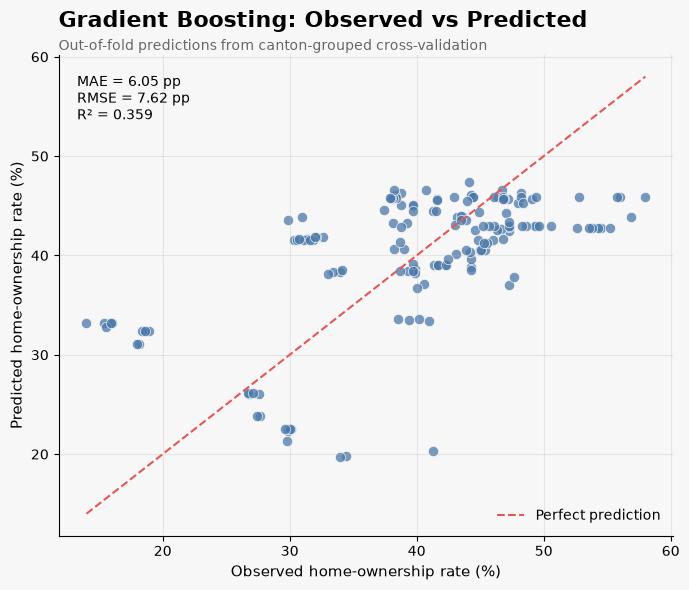

Figure saved to: /Users/eloy/Documents/HSLU-CAS_ML/HSLU-CAS_ML-CAS Project/swiss-data-intelligence/reports/figures/gradient_boosting_observed_vs_predicted.png


In [29]:
# Plot observed versus out-of-fold predicted home-ownership rates.
fig, ax = plt.subplots(
    figsize=(7, 6)
)

fig.patch.set_facecolor("#F7F7F7")
ax.set_facecolor("#F7F7F7")


ax.scatter(
    prediction_results[target],
    prediction_results["PREDICTED_HOME_OWNERSHIP_RATE"],
    color="#4C78A8",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    s=55,
)


# Define common limits for both axes.
plot_min = min(
    prediction_results[target].min(),
    prediction_results["PREDICTED_HOME_OWNERSHIP_RATE"].min(),
)

plot_max = max(
    prediction_results[target].max(),
    prediction_results["PREDICTED_HOME_OWNERSHIP_RATE"].max(),
)


# Add the perfect-prediction reference line.
ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    color="#E45756",
    linewidth=1.5,
    label="Perfect prediction",
)


ax.set_xlabel(
    "Observed home-ownership rate (%)",
    fontsize=11,
)

ax.set_ylabel(
    "Predicted home-ownership rate (%)",
    fontsize=11,
)

ax.set_title(
    "Gradient Boosting: Observed vs Predicted",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Out-of-fold predictions from canton-grouped cross-validation",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

ax.text(
    0.03,
    0.96,
    (
        f"MAE = {gradient_boosting_mae:.2f} pp\n"
        f"RMSE = {gradient_boosting_rmse:.2f} pp\n"
        f"R² = {gradient_boosting_r2:.3f}"
    ),
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=10,
)


ax.grid(
    alpha=0.25,
    linewidth=0.8,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
)

plt.tight_layout()

# Save the out-of-fold prediction figure for the final report.
figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "gradient_boosting_observed_vs_predicted.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path}")

Out-of-fold predictions were used for all graphical and error analyses. Consequently, each plotted prediction was generated without using observations from the corresponding canton during model training, avoiding an optimistic in-sample representation of model performance.

***REPORT NOTE*** — Prediction behaviour

The out-of-fold prediction analysis shows that Gradient Boosting captures a meaningful part of the cross-cantonal variation in home-ownership rates, but prediction errors are not uniformly distributed. Predictions tend to be closer to the centre of the observed target distribution, with particularly low home-ownership rates often being overestimated and particularly high rates underestimated. Several additional large errors are visible among intermediate observations. This suggests that demographic and household characteristics alone do not fully capture the structural differences of some cantons.

### Error Analysis by Canton

Prediction errors are aggregated by canton to identify whether model
performance is systematically weaker for particular geographic units.

Because each canton contains six yearly observations, the mean absolute error
provides a compact measure of the model's ability to generalise to each
previously unseen canton.

In [18]:
# Aggregate out-of-fold prediction errors by canton.
canton_errors = (
    prediction_results
    .groupby(
        ["GEO", "CANTON"],
        as_index=False,
    )
    .agg(
        MEAN_ACTUAL=(
            target,
            "mean",
        ),
        MEAN_PREDICTED=(
            "PREDICTED_HOME_OWNERSHIP_RATE",
            "mean",
        ),
        MAE=(
            "ABSOLUTE_ERROR",
            "mean",
        ),
        MEAN_ERROR=(
            "ERROR",
            "mean",
        ),
    )
)


# Sort cantons from largest to smallest average prediction error.
canton_errors = canton_errors.sort_values(
    "MAE",
    ascending=False,
).reset_index(drop=True)


display(
    canton_errors.round(2)
)

,GEO,CANTON,MEAN_ACTUAL,MEAN_PREDICTED,MAE,MEAN_ERROR
0,CH031,Basel-Stadt,15.43,33.11,17.67,-17.67
1,CH013,Genève,18.45,31.97,13.52,-13.52
2,CH024,Neuchâtel,30.65,42.33,11.68,-11.68
3,CH012,Valais / Wallis,54.00,42.74,11.26,11.26
4,CH066,Zug,31.87,41.70,9.83,-9.83
5,CH054,Appenzell Innerrhoden,54.82,45.51,9.30,9.30
6,CH061,Luzern,33.82,32.17,7.95,1.65
7,CH021,Bern / Berne,38.25,45.94,7.69,-7.69
8,CH011,Vaud,29.88,22.30,7.58,7.58
9,CH065,Nidwalden,39.08,45.48,6.40,-6.40


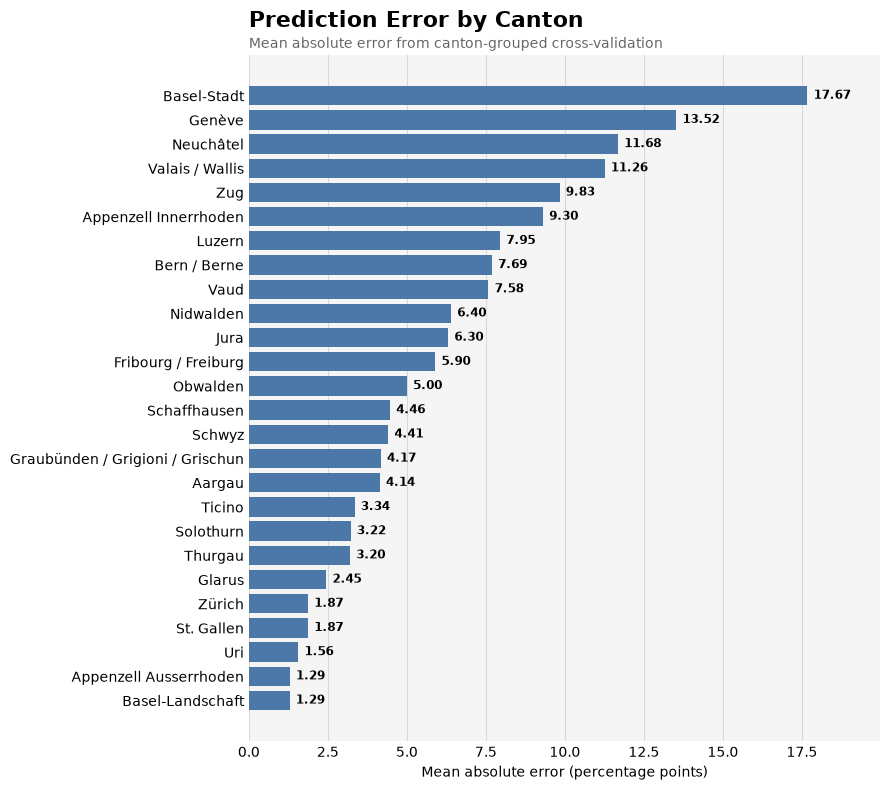

Figure saved to: /Users/eloy/Documents/HSLU-CAS_ML/HSLU-CAS_ML-CAS Project/swiss-data-intelligence/reports/figures/gradient_boosting_mae_by_canton.png


In [34]:
# Prepare canton-level MAE values for visualization.
# The values are sorted so that the largest prediction errors
# are immediately visible.
canton_mae_plot = (
    canton_errors[
        [
            "CANTON",
            "MAE",
        ]
    ]
    .sort_values(
        "MAE",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("#F5F5F5")

bars = ax.barh(
    canton_mae_plot["CANTON"],
    canton_mae_plot["MAE"],
    color="#4C78A8",
)

# Display the exact MAE next to each canton.
for bar, value in zip(
    bars,
    canton_mae_plot["MAE"],
):
    ax.text(
        value + 0.20,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=8.5,
        fontweight="bold",
    )

ax.set_title(
    "Prediction Error by Canton",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Mean absolute error from canton-grouped cross-validation",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

ax.set_xlabel(
    "Mean absolute error (percentage points)"
)
ax.set_ylabel("")

# Leave space for the numerical labels at the end of the bars.
ax.set_xlim(
    0,
    canton_mae_plot["MAE"].max() * 1.13,
)

ax.grid(
    axis="x",
    color="#D9D9D9",
    linewidth=0.8,
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
)

plt.tight_layout()

# Save a high-resolution version for the final report.
figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "gradient_boosting_mae_by_canton.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [19]:
# Inspect the relationship between canton names and geographic identifiers.
canton_mapping_check = (
    df[
        [
            "GEO",
            "CANTON",
        ]
    ]
    .drop_duplicates()
    .sort_values("GEO")
    .reset_index(drop=True)
)

display(canton_mapping_check)

,GEO,CANTON
0,CH011,Vaud
1,CH012,Valais / Wallis
2,CH013,Genève
3,CH021,Bern / Berne
4,CH022,Fribourg / Freiburg
5,CH023,Solothurn
6,CH024,Neuchâtel
7,CH025,Jura
8,CH031,Basel-Stadt
9,CH032,Basel-Landschaft


***REPORT NOTE*** - Error analysis

Prediction errors were strongly heterogeneous across cantons. The largest mean absolute errors were observed for Basel-Stadt (17.67 percentage points), Genève (13.52), Neuchâtel (11.68), Valais (11.26), Zug (9.83), and Appenzell Innerrhoden (9.30). The model substantially overestimated home ownership in several low-ownership cantons and underestimated it in some high-ownership cantons. However, prediction difficulty was not determined solely by the target level. For example, Zürich had a relatively low average home-ownership rate but was predicted with substantially lower error. This indicates that demographic and household composition alone do not fully explain the structural differences between Swiss cantons.

## Feature Importance

After evaluating predictive performance using out-of-fold predictions, the
Gradient Boosting model is fitted to the complete dataset for descriptive
interpretation of feature importance.

These feature importances describe how the fitted model uses the available
predictors. They should not be interpreted as causal effects.

In [20]:
# Fit the selected model on the complete dataset for
# descriptive feature-importance analysis.
final_gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)

final_gradient_boosting_model.fit(
    X,
    y,
)


# Extract and rank the model's feature importances.
feature_importance = pd.DataFrame(
    {
        "FEATURE": X.columns,
        "IMPORTANCE": (
            final_gradient_boosting_model.feature_importances_
        ),
    }
).sort_values(
    "IMPORTANCE",
    ascending=False,
).reset_index(drop=True)


display(
    feature_importance.round(3)
)

,FEATURE,IMPORTANCE
0,SHARE_AGE_20_39,0.624
1,LOG_TOTAL_POPULATION,0.080
2,SHARE_4_PERSON_HOUSEHOLDS,0.071
3,SHARE_AGE_40_64,0.068
4,SHARE_AGE_65_PLUS,0.054
5,SHARE_2_PERSON_HOUSEHOLDS,0.049
6,SHARE_5_PERSON_HOUSEHOLDS,0.037
7,SHARE_3_PERSON_HOUSEHOLDS,0.009
8,SHARE_1_PERSON_HOUSEHOLDS,0.008


***REPORT NOTE*** - Feature importance

The fitted Gradient Boosting model assigned substantially greater importance to the share of the population aged 20 to 39 than to any other predictor. This feature accounted for 0.624 of the model's impurity-based feature importance, followed by log-transformed total population (0.080), the share of four-person households (0.071), and the population share aged 40 to 64 (0.068). These values describe how the fitted model uses the available predictors and should not be interpreted as causal effects or as proportions of target variance explained. Correlation among compositional predictors may also affect how importance is distributed across features.

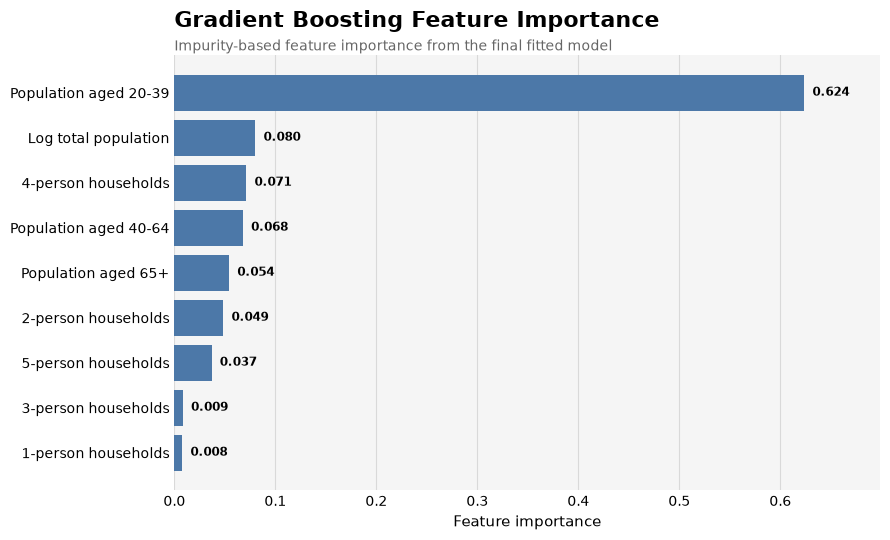

Figure saved to: /Users/eloy/Documents/HSLU-CAS_ML/HSLU-CAS_ML-CAS Project/swiss-data-intelligence/reports/figures/gradient_boosting_feature_importance.png


In [38]:
# Create readable labels for the final feature-importance figure.
feature_labels = {
    "SHARE_AGE_20_39": "Population aged 20-39",
    "LOG_TOTAL_POPULATION": "Log total population",
    "SHARE_4_PERSON_HOUSEHOLDS": "4-person households",
    "SHARE_AGE_40_64": "Population aged 40-64",
    "SHARE_AGE_65_PLUS": "Population aged 65+",
    "SHARE_2_PERSON_HOUSEHOLDS": "2-person households",
    "SHARE_5_PERSON_HOUSEHOLDS": "5-person households",
    "SHARE_3_PERSON_HOUSEHOLDS": "3-person households",
    "SHARE_1_PERSON_HOUSEHOLDS": "1-person households",
}

feature_importance_plot = feature_importance.copy()

feature_importance_plot["FEATURE_LABEL"] = (
    feature_importance_plot["FEATURE"]
    .map(feature_labels)
)

# Sort ascending so the most important feature appears at the top
# of the horizontal bar chart.
feature_importance_plot = (
    feature_importance_plot
    .sort_values("IMPORTANCE")
)

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("#F5F5F5")

bars = ax.barh(
    feature_importance_plot["FEATURE_LABEL"],
    feature_importance_plot["IMPORTANCE"],
    color="#4C78A8",
)

# Display the exact relative importance next to each bar.
for bar, value in zip(
    bars,
    feature_importance_plot["IMPORTANCE"],
):
    ax.text(
        value + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=8.5,
        fontweight="bold",
    )

ax.set_title(
    "Gradient Boosting Feature Importance",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Impurity-based feature importance from the final fitted model",
    transform=ax.transAxes,
    fontsize=10,
    color="#666666",
)

ax.set_xlabel(
    "Feature importance",
    fontsize=11,
)

ax.set_ylabel("")

# Leave enough horizontal space for the numerical labels.
ax.set_xlim(
    0,
    feature_importance_plot["IMPORTANCE"].max() * 1.12,
)

ax.grid(
    axis="x",
    color="#D9D9D9",
    linewidth=0.8,
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
)

plt.tight_layout()

# Save a high-resolution version for the final report.
figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "gradient_boosting_feature_importance.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved to: {figure_path}")

## Model Summary and Conclusions

The modelling analysis evaluated whether demographic structure, household
composition, and canton population size can predict differences in
home-ownership rates across Swiss cantons.

Because the dataset contains repeated yearly observations for each canton,
five-fold GroupKFold cross-validation was used with canton as the grouping
variable. This ensured that observations from the same canton never appeared
simultaneously in training and validation data.

Four regression approaches were evaluated. The mean-based baseline achieved
an MAE of 7.51 percentage points. Linear regression performed worse than the
baseline, with an MAE of 8.71 percentage points, indicating that a simple
linear relationship does not generalise effectively to unseen cantons.

Both nonlinear models improved upon the baseline. Random Forest achieved an
MAE of 6.56 percentage points, while Gradient Boosting provided the strongest
performance with an MAE of 6.05 percentage points, an RMSE of 7.62 percentage
points, and an out-of-fold R² of 0.359. This corresponds to an approximately
19.4% reduction in MAE relative to the baseline.

Error analysis showed substantial differences in predictive performance
between cantons. Some cantons, particularly Basel-Stadt, Genève, Neuchâtel,
Valais, Zug, and Appenzell Innerrhoden, remained difficult to predict from the
available features. This indicates that demographic and household composition
alone do not fully capture the structural factors associated with cantonal
home-ownership rates.

Feature-importance analysis of the fitted Gradient Boosting model identified
the population share aged 20-39 as the most influential predictor within the
available feature set. However, feature importance represents predictive use
within the model and should not be interpreted as evidence of causality.

Overall, the results provide evidence that demographic and household
characteristics contain useful predictive information about differences in
home-ownership rates across Swiss cantons. The stronger performance of the
nonlinear models suggests that these relationships are not adequately captured
by a simple linear specification. Nevertheless, the remaining prediction
error indicates that additional structural variables, such as housing prices,
income, urbanisation, or housing-market characteristics, could provide useful
information in future extensions of the analysis.

REPORT NOTE - Final ML result

Using canton-grouped cross-validation, Gradient Boosting achieved the strongest predictive performance with an MAE of 6.05 percentage points, RMSE of 7.62 percentage points, and R² of 0.359. This reduced MAE by approximately 19.4% relative to the mean-based baseline. Nonlinear models clearly outperformed linear regression, suggesting nonlinear relationships between demographic and household characteristics and cantonal home-ownership rates. However, substantial canton-specific errors remained, highlighting both the limitations of the available predictors and opportunities for incorporating additional socioeconomic and housing-market variables.

## Temporal Holdout Validation

As a complementary validation experiment, the selected Gradient Boosting model
is trained using observations from 2019 to 2023 and evaluated on 2024.

This experiment addresses a different generalisation scenario from the primary
canton-grouped cross-validation. GroupKFold evaluates predictions for previously
unseen cantons, whereas the temporal holdout evaluates predictions for a new
year of cantons already represented during training.

The temporal experiment is therefore reported separately and does not replace
the primary group-aware model evaluation.

In [22]:
# Define the temporal training and test periods.
train_mask = df["YEAR"] < 2024
test_mask = df["YEAR"] == 2024


# Create temporal training and test datasets using exactly
# the same predictors as in the main modelling experiment.
X_train_temporal = X[train_mask]
X_test_temporal = X[test_mask]

y_train_temporal = y[train_mask]
y_test_temporal = y[test_mask]


print(
    "Training observations:",
    len(X_train_temporal),
)

print(
    "Test observations:",
    len(X_test_temporal),
)

print(
    "Training years:",
    sorted(df.loc[train_mask, "YEAR"].unique()),
)

print(
    "Test years:",
    sorted(df.loc[test_mask, "YEAR"].unique()),
)

Training observations: 130
Test observations: 26
Training years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Test years: [np.int64(2024)]


In [23]:
# Fit a mean-based baseline using only the temporal training period.
temporal_baseline = DummyRegressor(
    strategy="mean",
)

temporal_baseline.fit(
    X_train_temporal,
    y_train_temporal,
)


# Predict the 2024 observations.
temporal_baseline_predictions = temporal_baseline.predict(
    X_test_temporal
)


# Evaluate the temporal baseline.
temporal_baseline_mae = mean_absolute_error(
    y_test_temporal,
    temporal_baseline_predictions,
)

temporal_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_temporal,
        temporal_baseline_predictions,
    )
)

temporal_baseline_r2 = r2_score(
    y_test_temporal,
    temporal_baseline_predictions,
)

In [24]:
# Train the selected Gradient Boosting specification using
# only observations from 2019 to 2023.
temporal_gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)

temporal_gradient_boosting.fit(
    X_train_temporal,
    y_train_temporal,
)


# Generate predictions for the unseen year 2024.
temporal_predictions = temporal_gradient_boosting.predict(
    X_test_temporal
)


# Evaluate predictions on the 2024 holdout.
temporal_mae = mean_absolute_error(
    y_test_temporal,
    temporal_predictions,
)

temporal_rmse = np.sqrt(
    mean_squared_error(
        y_test_temporal,
        temporal_predictions,
    )
)

temporal_r2 = r2_score(
    y_test_temporal,
    temporal_predictions,
)

In [25]:
print("Temporal Holdout: 2024")
print()

print(
    f"Baseline MAE:  "
    f"{temporal_baseline_mae:.2f} percentage points"
)

print(
    f"Baseline RMSE: "
    f"{temporal_baseline_rmse:.2f} percentage points"
)

print(
    f"Baseline R²:   "
    f"{temporal_baseline_r2:.3f}"
)

print()

print(
    f"Gradient Boosting MAE:  "
    f"{temporal_mae:.2f} percentage points"
)

print(
    f"Gradient Boosting RMSE: "
    f"{temporal_rmse:.2f} percentage points"
)

print(
    f"Gradient Boosting R²:   "
    f"{temporal_r2:.3f}"
)

Temporal Holdout: 2024

Baseline MAE:  6.85 percentage points
Baseline RMSE: 9.34 percentage points
Baseline R²:   -0.004

Gradient Boosting MAE:  2.29 percentage points
Gradient Boosting RMSE: 3.16 percentage points
Gradient Boosting R²:   0.885


***REPORT NOTE*** - Validation scenarios

Model performance differed substantially depending on the generalisation scenario. Under canton-grouped cross-validation, where entire cantons were excluded from model training, Gradient Boosting achieved an MAE of 6.05 percentage points and an R² of 0.359. In contrast, when trained on 2019-2023 observations and evaluated on the 2024 observations of the same 26 cantons, the model achieved an MAE of 2.29 percentage points, an RMSE of 3.16 percentage points, and an R² of 0.885.

This difference is consistent with the panel structure identified during EDA, where between-canton variation was approximately 10.5 times greater than average within-canton temporal variation. The model therefore generalises substantially better to a new year for previously observed cantons than to completely unseen cantons. The temporal result should consequently not be interpreted as evidence of equivalent performance for new geographic units.

In [26]:
# -------------------------------------------------------------------
# Persistence baseline for temporal validation
# -------------------------------------------------------------------

# Use each canton's 2023 observed home-ownership rate as the
# prediction for that same canton in 2024.
actual_2023 = (
    df[df["YEAR"] == 2023][
        ["GEO", "HOME_OWNERSHIP_RATE"]
    ]
    .rename(
        columns={
            "HOME_OWNERSHIP_RATE": "PREDICTION_2024",
        }
    )
)

actual_2024 = df[
    df["YEAR"] == 2024
][
    ["GEO", "HOME_OWNERSHIP_RATE"]
]


persistence_results = actual_2024.merge(
    actual_2023,
    on="GEO",
    how="inner",
    validate="one_to_one",
)


# Evaluate the persistence baseline.
persistence_mae = mean_absolute_error(
    persistence_results["HOME_OWNERSHIP_RATE"],
    persistence_results["PREDICTION_2024"],
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        persistence_results["HOME_OWNERSHIP_RATE"],
        persistence_results["PREDICTION_2024"],
    )
)

persistence_r2 = r2_score(
    persistence_results["HOME_OWNERSHIP_RATE"],
    persistence_results["PREDICTION_2024"],
)


print("Persistence baseline: 2023 → 2024")
print()

print(
    f"MAE:  {persistence_mae:.2f} percentage points"
)

print(
    f"RMSE: {persistence_rmse:.2f} percentage points"
)

print(
    f"R²:   {persistence_r2:.3f}"
)

Persistence baseline: 2023 → 2024

MAE:  1.20 percentage points
RMSE: 1.78 percentage points
R²:   0.964


***REPORT NOTE*** 

Gradient Boosting achieved an R² of 0.885 when predicting 2024 from 2019-2023 observations. However, a persistence baseline using each canton's 2023 home-ownership rate as its 2024 prediction achieved an R² of 0.964 and an MAE of only 1.20 percentage points. This demonstrates that the strong temporal performance is largely explained by the high year-to-year persistence of cantonal home-ownership rates rather than superior predictive information extracted by the machine-learning model.

### Temporal Validation Conclusion

Gradient Boosting achieved strong apparent predictive performance when trained
on observations from 2019 to 2023 and evaluated on 2024, with an MAE of 2.29
percentage points and an R² of 0.885.

However, a persistence baseline using each canton's 2023 observed
home-ownership rate as its prediction for 2024 performed substantially better,
achieving an MAE of 1.20 percentage points and an R² of 0.964.

This result demonstrates that the strong temporal predictability of the target
is largely driven by the high year-to-year persistence of cantonal
home-ownership rates. Consequently, the temporal holdout should not be
interpreted as evidence that the machine-learning model provides superior
short-term forecasts.

The canton-grouped cross-validation therefore remains the primary evaluation
for assessing whether demographic and household characteristics contain
generalizable predictive information across cantons.

***PRESENTATION NOTE***

*“The target exhibits strong temporal persistence. A simple persistence baseline using the previous year's value outperformed Gradient Boosting, indicating that the high temporal R² was primarily driven by target stability rather than by superior predictive power of the ML model.”*

In [27]:
# -------------------------------------------------------------------
# Final model training and persistence
# -------------------------------------------------------------------

# Train the selected Gradient Boosting specification on the complete
# modelling dataset for use by the Streamlit application.
#
# This fitted model is used for application inference only.
# Reported performance remains based on out-of-sample validation.
final_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)

final_model.fit(
    X,
    y,
)


# Define the directory where trained model artifacts are stored.
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_PATH = (
    MODEL_DIR
    / "home_ownership_gradient_boosting.joblib"
)


# Store the trained model together with the exact feature schema
# required during inference.
model_artifact = {
    "model": final_model,
    "features": list(X.columns),
}


# Persist the artifact so that the Streamlit application can
# load the trained model without retraining it.
joblib.dump(
    model_artifact,
    MODEL_PATH,
)


print(
    f"Model saved to: {MODEL_PATH}"
)

print(
    f"Number of model features: {len(X.columns)}"
)

Model saved to: /Users/eloy/Documents/HSLU-CAS_ML/HSLU-CAS_ML-CAS Project/swiss-data-intelligence/models/home_ownership_gradient_boosting.joblib
Number of model features: 9
